# AG-HYPOPT · Trial 06

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Five trials, all six families now covered, all at `sigma_weight` ~0.23-0.51, no divergences. Current
ranking (objective, lower better): **trial_05** `cvm_fwhm` **0.0777** (best), **trial_01** `w1_2d`
**0.0895**, **trial_04** `w1_fwhm` **0.0908**, **trial_02** `energy_2d` **0.0996**, **trial_03** `mmd_2d`
**0.1833**. The KDE reference is **0.080328**, so `cvm_fwhm` is the first family to edge past the control
(-0.0026, within combined uncertainty); its gain came from the gamma channel (best gamma RMSE 2.47 / rel
24.6 % / bias -1.92 of the campaign), while mu stayed low at high T everywhere. The FWHM-only families
(`w1_fwhm`, `cvm_fwhm`) make `sigma_weight` inert. Phase is now `trials` (5/5) -> the proposer switches
from uniform exploration to EI-guided exploitation.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_06'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (5/5 trials)
ID |     ei | params
 1 | 0.2846 | {"loss_family": "mmd_2d", "sigma_weight": 0.36906723979537825}
 2 | 3.3650 | {"loss_family": "energy_2d", "sigma_weight": 0.22761194860090356}
 3 | 1.4925 | {"loss_family": "w1_fwhm", "sigma_weight": 0.6799176611640223}
 4 | 2.1739 | {"loss_family": "kde", "sigma_weight": 0.850191346808787}
 5 | 3.5469 | {"loss_family": "kde", "sigma_weight": 0.19217875335791038}
 6 | 3.7979 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.20743926620697473}
 7 | 2.8166 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.6274679337030739}
 8 | 0.2606 | {"loss_family": "kde", "sigma_weight": 0.49726791274147364}
 9 |      - | {"loss_family": "cvm_fwhm", "sigma_weight": 0.5398572043444361}
10 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.10688007856904247}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The campaign has entered the exploitation phase (5/5): the table now carries an `ei` column, highest
first. The best recorded trial is trial_05 (`cvm_fwhm`, 0.0777), the only family to beat the KDE control
(0.0803).

The EI ranking puts candidate **6** (`cvm_fwhm`, sw 0.2074) on top (ei 3.7979), then candidate 5
(`kde`, sw 0.1922, ei 3.5469) and candidate 2 (`energy_2d`, ei 3.3650). In an exploitation phase the
natural move is to follow the evidence: re-run the best family. Since `cvm_fwhm` is FWHM-only,
`sigma_weight` is inert, so candidate 6 is a fresh-seed **replication of trial_05's configuration** -
which is exactly what is needed before trusting a 0.0026 margin over the control: it tests whether the
`cvm_fwhm` win is robust or a single lucky draw. (Candidates 9/10 have no `ei` - the proposer did not
rank them.)

I choose candidate 6.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 6             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'cvm_fwhm', 'sigma_weight': 0.20743926620697473}
Running  1nW Trans05 ... 

μ 9.39 -> 5.44 | γ 8.5 -> 4.21 | NLL 158.45


Running  1nW Trans20 ... 

μ 17.32 -> 22.54 | γ 8.5 -> 5.94 | NLL 0.84


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 61.59 | γ 14.1 -> 13.86 | NLL 0.11


Running 3nW Trans100 ... 

μ 175.71 -> 93.80 | γ 14.1 -> 13.53 | NLL 16.60



Total: 7.8 min


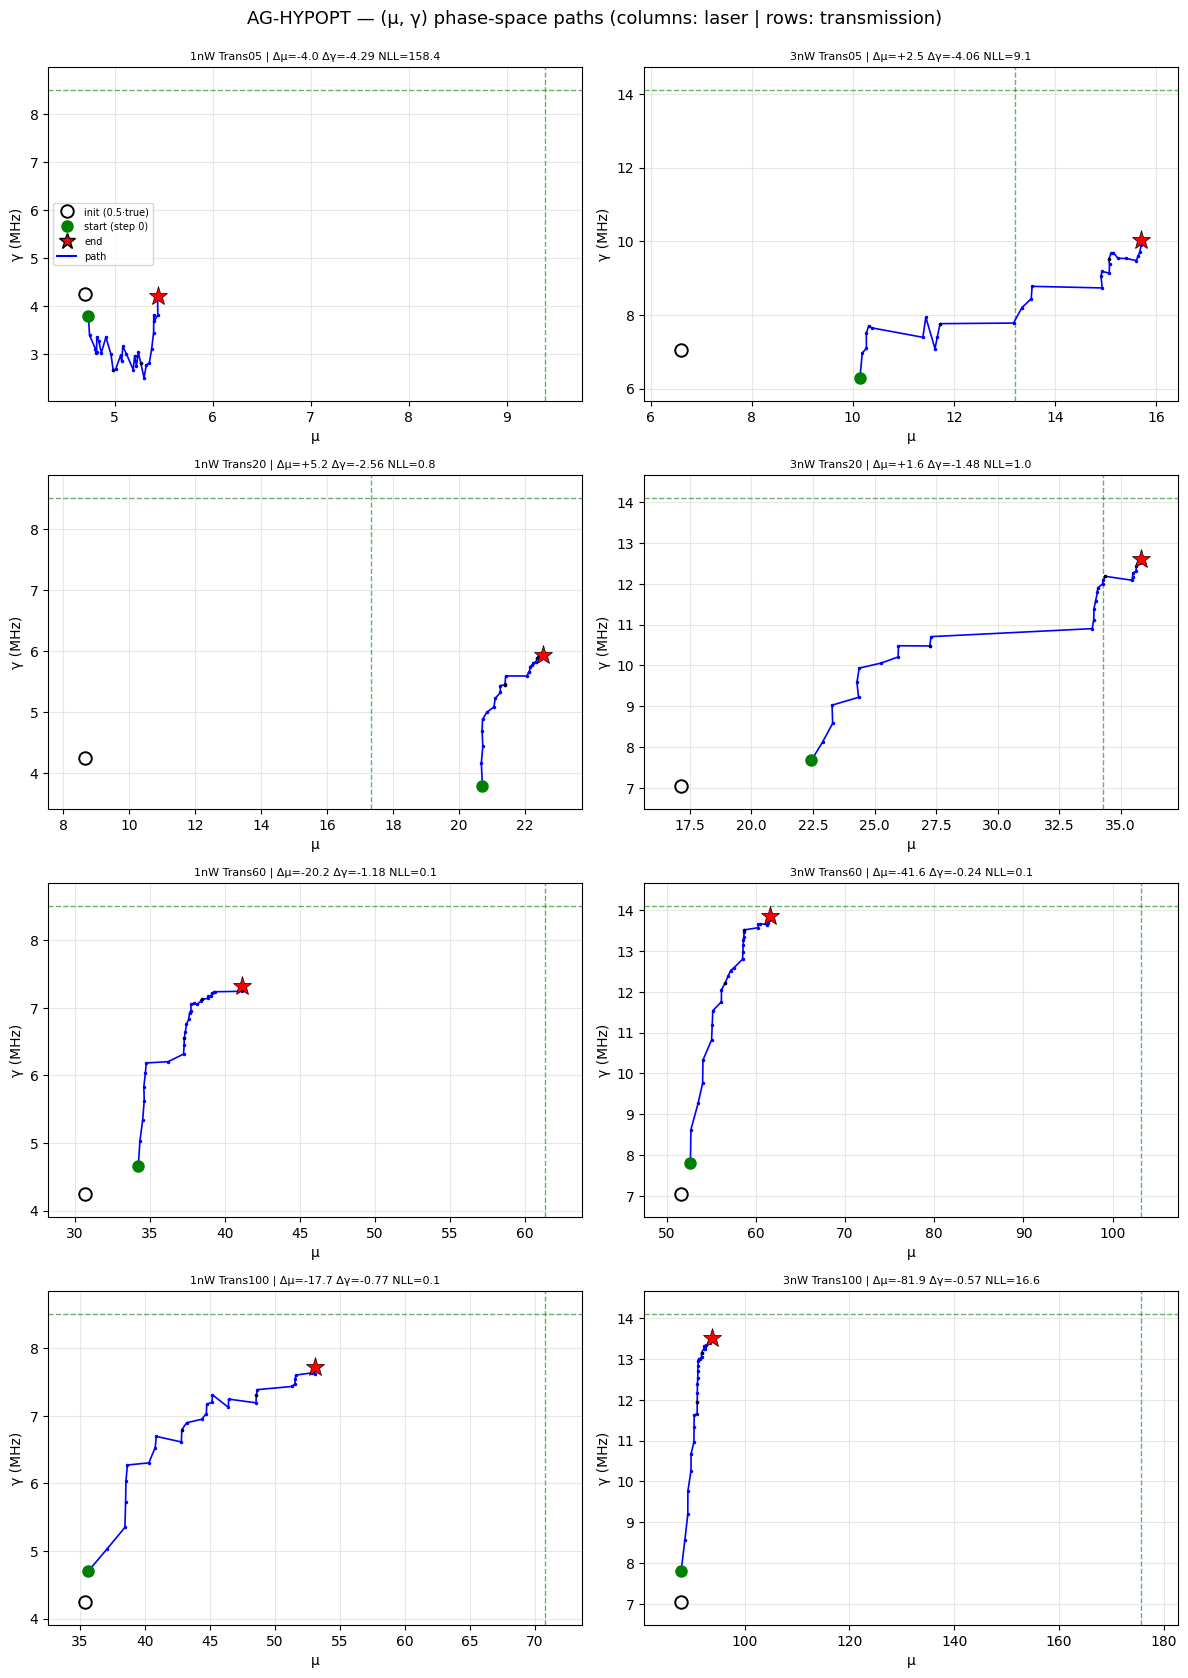

trial finished in 7.8 min
objective = 0.0764 ± 0.0205
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.44   -42.1 |     8.50    4.21   -50.4
1nW Trans20       17.32   22.54   +30.2 |     8.50    5.94   -30.1
1nW Trans60       61.37   41.14   -33.0 |     8.50    7.32   -13.8
1nW Trans100       70.82   53.12   -25.0 |     8.50    7.73    -9.1
3nW Trans05       13.20   15.70   +18.9 |    14.10   10.04   -28.8
3nW Trans20       34.28   35.83    +4.5 |    14.10   12.62   -10.5
3nW Trans60      103.20   61.59   -40.3 |    14.10   13.86    -1.7
3nW Trans100      175.71   93.80   -46.6 |    14.10   13.53    -4.1

weighted objective (T-graded, cap=1.0) = 0.0764 | diverged cells: 0
μ: RMSE 33.939 (rel 32.7%, bias -19.517) | γ: RMSE 2.398 (rel 24.2%, bias -1.895)


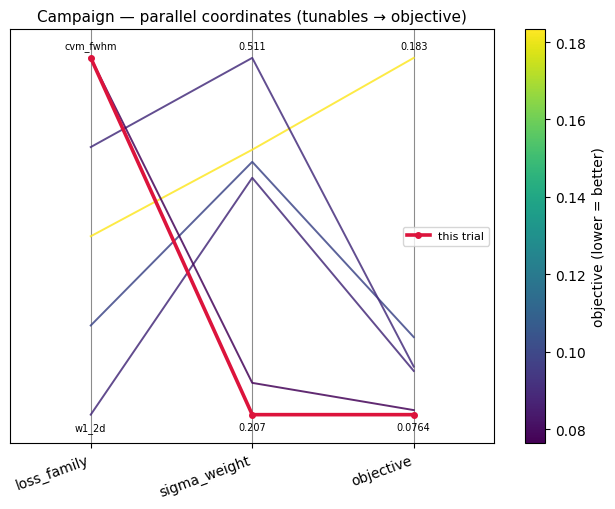

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'cvm_fwhm', sigma_weight: 0.2074}` (candidate 6, top EI).
Trial time 7.8 min, objective **0.0764 +/- 0.0205**, **0 diverged cells**. This is a **new campaign
best**, improving on trial_05's `cvm_fwhm` (sw 0.2345 -> 0.0777) and still ahead of the KDE control
(0.0803). Note that `sigma_weight` is *not* fully inert even for the FWHM-only family: trial_06 repeats
trial_05's low-count cells bit-for-bit (1nW Trans05 identical at mu 5.44 / gamma 4.21; 1nW Trans20
almost so) but differs in the higher-T cells, so the small sw change moved the objective by -0.0013.

**Per-cell behaviour.**

- 1nW Trans05: mu -42.1 %, gamma 8.5 -> 4.21 (-50.4 %) - identical to trial_05.
- 1nW Trans20: mu +30.2 %, gamma -30.1 %.
- 1nW Trans60 / Trans100: mu -33.0 % / -25.0 %, gamma -13.8 % / -9.1 % (Trans60 gamma improved from
  -15.3 % to -13.8 %, Trans100 worsened from -6.4 % to -9.1 %).
- 3nW Trans05 / Trans20: mu +18.9 % / +4.5 %, gamma -28.8 % / -10.5 %.
- 3nW Trans60 / Trans100: mu -40.3 % / -46.6 %, gamma -1.7 % / -4.1 %.

**Aggregates.** mu: RMSE 33.94 (rel 32.7 %), bias -19.52; gamma: RMSE 2.40 (rel 24.2 %), bias -1.90 -
again the **best gamma of the campaign** (trial_05 was 2.47 / 24.6 %), with mu essentially unchanged.

**Summary:** Re-running `cvm_fwhm` at sw 0.2074 reproduces the family's win and improves it to objective
0.0764, still beating the KDE control (0.0803), with the campaign's best gamma and no divergences.
**Key insight:** The `cvm_fwhm` advantage is reproducible across two seeds (0.0777 then 0.0764) and its
benefit lives in the gamma channel, while mu stays at the same rel ~33 % level as every other family.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'cvm_fwhm (sigma_weight 0.2074) improves the campaign best to objective 0.0764, reproducing the family win over the KDE control (0.0803) with the best gamma of the campaign.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'The cvm_fwhm advantage is reproducible across two seeds (0.0777 then 0.0764) and its benefit lives in the gamma channel, while mu stays at the same rel ~33 percent level as every other family.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_06 | current best: trial_06


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_07.ipynb. Open it and follow its cells from the top.
